In [1]:
import pandas as pd
import numpy as np

In [2]:
url='C:/Users/Gunee/Downloads/Dataset1.csv'
df=pd.read_csv(url)

In [3]:
df.head()

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


## TASK 1

#### 1.1

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186074 entries, 0 to 186073
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   SN              186074 non-null  int64 
 1   Train_No        186074 non-null  int64 
 2   Station_Code    186074 non-null  object
 3   1A              186074 non-null  int64 
 4   2A              186074 non-null  int64 
 5   3A              186074 non-null  int64 
 6   SL              186074 non-null  int64 
 7   Station_Name    186074 non-null  object
 8   Route_Number    186074 non-null  int64 
 9   Arrival_time    186074 non-null  object
 10  Departure_Time  186074 non-null  object
 11  Distance        186074 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 17.0+ MB


In [5]:
df.shape

(186074, 12)

In [6]:
df.describe()

,SN,Train_No,1A,2A,3A,SL,Route_Number,Distance
count,186074.000000,186074.000000,186074.000000,186074.000000,186074.000000,186074.000000,186074.0,186074.000000
mean,13.914695,42157.747455,1506.769189,1225.415351,944.061513,662.735777,1.0,281.353838
std,12.779368,25090.080221,2418.719821,1934.975856,1451.231892,967.524012,0.0,483.743964
min,1.000000,107.000000,100.000000,100.000000,100.000000,100.000000,1.0,0.000000
25%,5.000000,17225.000000,215.000000,192.000000,169.000000,146.000000,1.0,23.000000
50%,11.000000,40050.000000,465.000000,392.000000,319.000000,246.000000,1.0,73.000000
75%,18.000000,57550.000000,1555.000000,1264.000000,973.000000,682.000000,1.0,291.000000
max,118.000000,99908.000000,21400.000000,17140.000000,12880.000000,8620.000000,1.0,4260.000000


#### 1.2

In [7]:
df=df.sort_values(['Train_No','Distance'])

In [8]:
df.head(20)

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
5,2,108,KRMI,265,232,199,166,KARMALI,1,21:04:00,21:06:00,33
6,3,108,THVM,355,304,253,202,THIVIM,1,21:26:00,21:28:00,51
7,4,108,SWV,515,432,349,266,SAWANTWADI R,1,22:25:00,00:00:00,83
8,1,128,MAO,100,100,100,100,MADGOAN JN.,1,19:40:00,19:40:00,0
9,2,128,KRMI,265,232,199,166,KARMALI,1,20:18:00,20:20:00,33


In [9]:
train_wise=df.groupby('Train_No').agg(
    Start=('Station_Name','first'), End=('Station_Name','last')
).reset_index()

In [10]:
train_wise.head()

,Train_No,Start,End
0,107,SAWANTWADI R,MADGOAN JN.
1,108,MADGOAN JN.,SAWANTWADI R
2,128,MADGOAN JN.,CHHATRAPATI
3,290,DELHI-SAFDAR,DELHI-SAFDAR
4,401,AURANGABAD,VARANASI JN.


#### 1.3

In [11]:
df['Distance'].describe()

count    186074.000000
mean        281.353838
std         483.743964
min           0.000000
25%          23.000000
50%          73.000000
75%         291.000000
max        4260.000000
Name: Distance, dtype: float64

In [12]:
t=df.groupby('Train_No').size()

In [13]:
t.describe()

count    11113.000000
mean        16.743814
std         12.993123
min          2.000000
25%          8.000000
50%         15.000000
75%         22.000000
max        118.000000
dtype: float64

#### 1.4

In [14]:
df.isnull().any()

SN                False
Train_No          False
Station_Code      False
1A                False
2A                False
3A                False
SL                False
Station_Name      False
Route_Number      False
Arrival_time      False
Departure_Time    False
Distance          False
dtype: bool

In [15]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
186064    False
186065    False
186066    False
186067    False
186068    False
Length: 186074, dtype: bool

In [16]:
df['Station_Name'].unique()

array(['SAWANTWADI R', 'THIVIM', 'KARMALI', ..., 'MANKHURD', 'CHEMBUR',
       'NERUL'], dtype=object)

#### 2.2

In [17]:
df['Arrival_time'] = pd.to_datetime(df['Arrival_time'], errors='coerce')
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], errors='coerce')

C:\Users\Gunee\AppData\Local\Temp\ipykernel_39580\2723140790.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_time'] = pd.to_datetime(df['Arrival_time'], errors='coerce')
C:\Users\Gunee\AppData\Local\Temp\ipykernel_39580\2723140790.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], errors='coerce')


In [18]:
df['Arrival_time'] = df['Arrival_time'].dt.strftime('%H:%M:%S')
df['Departure_Time'] = df['Departure_Time'].dt.strftime('%H:%M:%S')

#### 2.3

In [19]:
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'])
df['Arrival_time'] = pd.to_datetime(df['Arrival_time'])

C:\Users\Gunee\AppData\Local\Temp\ipykernel_39580\4181819187.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Departure_Time'] = pd.to_datetime(df['Departure_Time'])
C:\Users\Gunee\AppData\Local\Temp\ipykernel_39580\4181819187.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_time'] = pd.to_datetime(df['Arrival_time'])


In [20]:
df['Arrival_time'] = pd.to_datetime(df['Arrival_time'], errors='coerce')
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], errors='coerce')

df = df.sort_values(['Train_No', 'Distance'])

journey = df.groupby('Train_No').agg(
    Start_Time=('Departure_Time', 'first'),
    End_Time=('Arrival_time', 'last')
).reset_index()
journey['Journey_Duration'] = journey['End_Time'] - journey['Start_Time']
journey['Journey_Duration'] = (journey['Journey_Duration'].apply(lambda x: x if x > pd.Timedelta(0) else x + pd.Timedelta(days=1)))

print(journey)

       Train_No          Start_Time            End_Time Journey_Duration
0           107 2026-03-01 10:25:00 2026-03-01 12:10:00  0 days 01:45:00
1           108 2026-03-01 20:30:00 2026-03-01 22:25:00  0 days 01:55:00
2           128 2026-03-01 19:40:00 2026-03-01 17:45:00  0 days 22:05:00
3           290 2026-03-01 18:30:00 2026-03-01 02:30:00  0 days 08:00:00
4           401 2026-03-01 21:30:00 2026-03-01 10:00:00  0 days 12:30:00
...         ...                 ...                 ...              ...
11108     99904 2026-03-01 08:57:00 2026-03-01 09:47:00  0 days 00:50:00
11109     99905 2026-03-01 09:57:00 2026-03-01 10:40:00  0 days 00:43:00
11110     99906 2026-03-01 15:40:00 2026-03-01 16:30:00  0 days 00:50:00
11111     99907 2026-03-01 16:38:00 2026-03-01 17:30:00  0 days 00:52:00
11112     99908 2026-03-01 23:00:00 2026-03-01 23:50:00  0 days 00:50:00

[11113 rows x 4 columns]


#### 2.4

In [21]:
t.head()

Train_No
107     4
108     4
128    22
290    14
401    12
dtype: int64

In [22]:
total_distance = df.groupby('Train_No')['Distance'].max().reset_index(name='Total_Distance')

In [23]:
total_distance.head()

,Train_No,Total_Distance
0,107,78
1,108,83
2,128,978
3,290,2694
4,401,1618


In [24]:
features = df.groupby('Train_No').agg(
    Total_Distance=('Distance', 'max'),
    Number_of_Stops=('Station_Name', 'count')
).reset_index()

print(features.head())

   Train_No  Total_Distance  Number_of_Stops
0       107              78                4
1       108              83                4
2       128             978               22
3       290            2694               14
4       401            1618               12


#### 3.1

In [25]:
journey['Duration_Minutes'] = journey['Journey_Duration'].dt.total_seconds()/ 60

In [26]:
journey.head()

,Train_No,Start_Time,End_Time,Journey_Duration,Duration_Minutes
0,107,2026-03-01 10:25:00,2026-03-01 12:10:00,0 days 01:45:00,105.0
1,108,2026-03-01 20:30:00,2026-03-01 22:25:00,0 days 01:55:00,115.0
2,128,2026-03-01 19:40:00,2026-03-01 17:45:00,0 days 22:05:00,1325.0
3,290,2026-03-01 18:30:00,2026-03-01 02:30:00,0 days 08:00:00,480.0
4,401,2026-03-01 21:30:00,2026-03-01 10:00:00,0 days 12:30:00,750.0


In [27]:
route_map = df[['Train_No', 'Route_Number']].drop_duplicates()
journey = journey.merge(route_map, on='Train_No', how='left')
journey.groupby('Route_Number')['Duration_Minutes'].mean()

Route_Number
1    276.790966
Name: Duration_Minutes, dtype: float64

In [45]:
journey=journey.merge(total_distance,on='Train_No')
journey.head()

,Train_No,Start_Time,End_Time,Journey_Duration,Duration_Minutes,Route_Number,Total_Distance_x,Total_Distance_y,Total_Distance
0,107,2026-03-01 10:25:00,2026-03-01 12:10:00,0 days 01:45:00,105.0,1,78,78,78
1,108,2026-03-01 20:30:00,2026-03-01 22:25:00,0 days 01:55:00,115.0,1,83,83,83
2,128,2026-03-01 19:40:00,2026-03-01 17:45:00,0 days 22:05:00,1325.0,1,978,978,978
3,290,2026-03-01 18:30:00,2026-03-01 02:30:00,0 days 08:00:00,480.0,1,2694,2694,2694
4,401,2026-03-01 21:30:00,2026-03-01 10:00:00,0 days 12:30:00,750.0,1,1618,1618,1618


#### 3.2

In [28]:
station_traffic = df.groupby('Station_Name')['Train_No'].nunique().reset_index(name='Train_Count')

station_traffic.head(10)

,Station_Name,Train_Count
0,.BAGHAJATIN,217
1,ABADA,90
2,ABHAIPUR,62
3,ABHANPUR JN.,12
4,ABHAYAPURI A,6
5,ABJUGANJ,6
6,ABOHAR,28
7,ABU ROAD,100
8,ABUTARA HALT,6
9,ACHAL GANJ,6


In [29]:
high_traffic = station_traffic.sort_values('Train_Count', ascending=False)

print(high_traffic.head(1))
print(high_traffic.tail(1))

     Station_Name  Train_Count
1755   CST-MUMBAI         1027
      Station_Name  Train_Count
6315  RAMGHAT  HAL            1


#### 3.3

In [30]:
journey['Duration_Minutes'].corr(features['Total_Distance'])

np.float64(0.6417006907563017)

This shows that they have a good relationship.

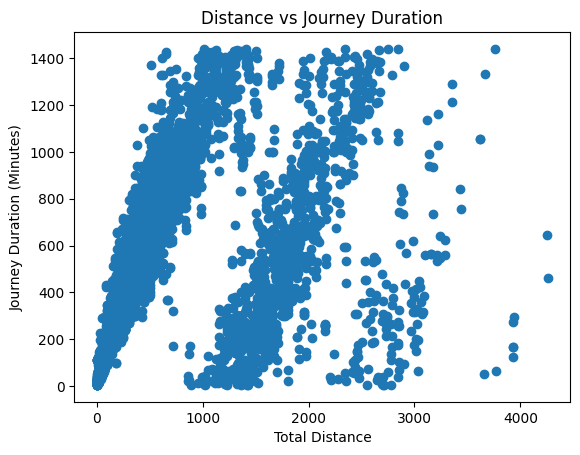

In [31]:
import matplotlib.pyplot as plt

plt.scatter(features['Total_Distance'], journey['Duration_Minutes'])
plt.xlabel("Total Distance")
plt.ylabel("Journey Duration (Minutes)")
plt.title("Distance vs Journey Duration")
plt.show()

#### 4.1

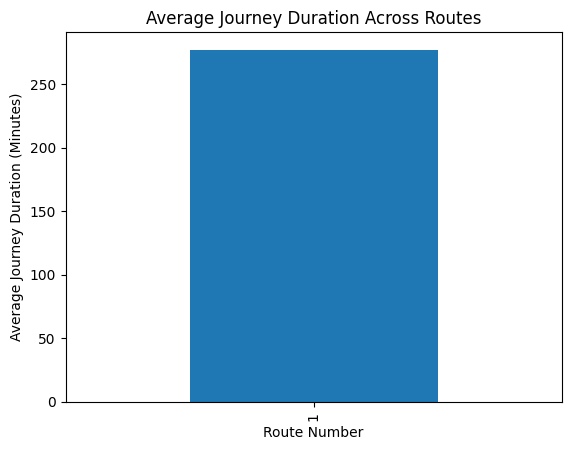

In [32]:
import matplotlib.pyplot as plt

route_avg = journey.groupby('Route_Number')['Duration_Minutes'].mean()

route_avg.plot(kind='bar')
plt.xlabel("Route Number")
plt.ylabel("Average Journey Duration (Minutes)")
plt.title("Average Journey Duration Across Routes")
plt.show()

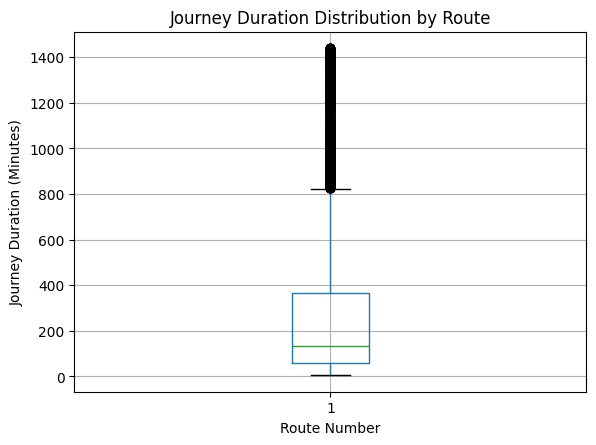

In [33]:
import matplotlib.pyplot as plt

journey.boxplot(column='Duration_Minutes', by='Route_Number')
plt.xlabel("Route Number")
plt.ylabel("Journey Duration (Minutes)")
plt.title("Journey Duration Distribution by Route")
plt.suptitle("")  # removes extra default title
plt.show()

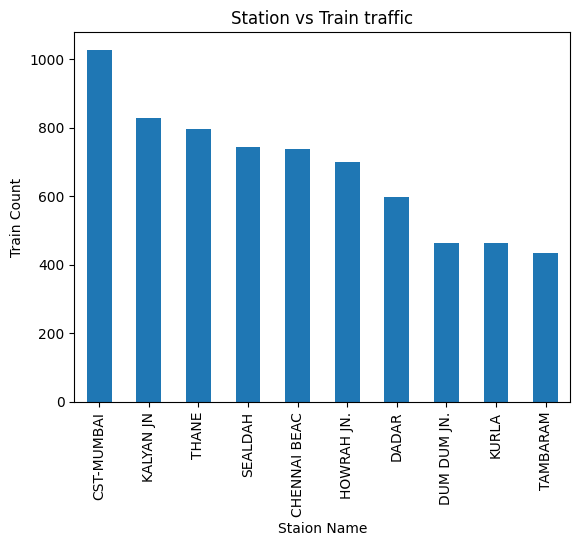

In [40]:
import matplotlib.pyplot as plt

station_traffic = df.groupby('Station_Name')['Train_No'].nunique()
station_traffic= station_traffic.sort_values(ascending=False).head(10)
station_traffic.plot(kind='bar')
plt.xlabel("Staion Name")
plt.ylabel("Train Count")
plt.title("Station vs Train traffic")
plt.show()

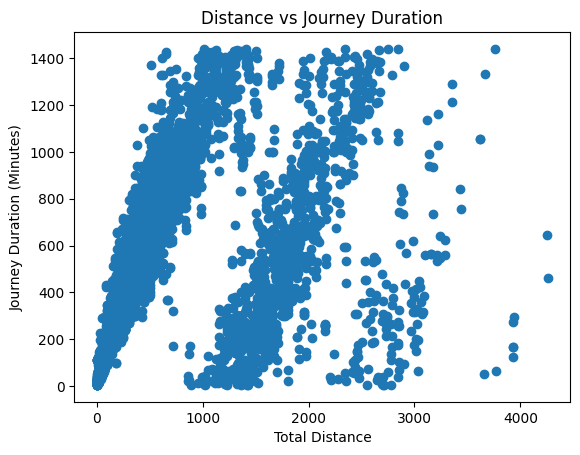

In [48]:
import matplotlib.pyplot as plt

plt.scatter(journey['Total_Distance'], journey['Duration_Minutes'])
plt.xlabel("Total Distance")
plt.ylabel("Journey Duration (Minutes)")
plt.title("Distance vs Journey Duration")
plt.show()

#### 5.1

In [49]:
features = df.groupby('Train_No').agg(
    Total_Distance=('Distance', 'max'),
    Number_of_Stops=('Station_Name', 'count')
).reset_index()

print(features.head())

   Train_No  Total_Distance  Number_of_Stops
0       107              78                4
1       108              83                4
2       128             978               22
3       290            2694               14
4       401            1618               12


In [60]:
features=features.merge(journey[['Train_No','Duration_Minutes']],on='Train_No')
features.head()

,Train_No,Total_Distance,Number_of_Stops,Duration_Minutes_x,Duration_Minutes_y
0,107,78,4,105.0,105.0
1,108,83,4,115.0,115.0
2,128,978,22,1325.0,1325.0
3,290,2694,14,480.0,480.0
4,401,1618,12,750.0,750.0


In [61]:
features = features.drop(columns=['Duration_Minutes_y'])
features = features.rename(columns={'Duration_Minutes_x':'Duration_Minutes'})

#### 5.2

In [62]:
from sklearn.model_selection import train_test_split
y_data = features['Duration_Minutes']
x_data=features.drop('Duration_Minutes',axis=1)
x_train, x_test, y_train, y_test =train_test_split(x_data, y_data, test_size=0.10,random_state=1)


#### 5.3

In [66]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()


In [67]:
X = x_train
Y = y_train
lr.fit(X,Y)

LinearRegression()

In [68]:
Y_hat = lr.predict(x_test)


In [69]:
Y_hat

array([420.06543103, 584.54381954, 623.00888294, ..., 354.85032721,
       935.34900383, 461.38214826])

In [72]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print("RMSE:", np.sqrt(mean_squared_error(y_test, Y_hat)))
print("MAE", mean_absolute_error(y_test, Y_hat))

RMSE: 235.2034923686849
MAE 160.83321105091247


#### 6 FINAL

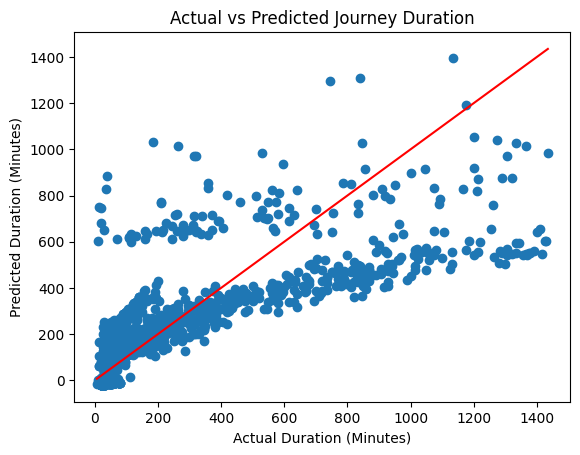

In [73]:
import matplotlib.pyplot as plt

plt.scatter(y_test, Y_hat)
plt.xlabel("Actual Duration (Minutes)")
plt.ylabel("Predicted Duration (Minutes)")
plt.title("Actual vs Predicted Journey Duration")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()